# Week 5: Streaming and Near-Real-Time Analytics

This notebook accompanies the Week 5 lecture on **Streaming and Near-Real-Time Analytics**.

We will implement and visualise the key algorithms and concepts from the slides — all in pure Python, without requiring a running Spark cluster.

### What we'll cover
1. **Batch vs Streaming** — side-by-side comparison of the two processing paradigms
2. **Reservoir Sampling** — uniform random sampling from an infinite stream
3. **Bloom Filters** — memory-efficient set membership with probabilistic guarantees
4. **AMS Sketch** — estimating frequency moments (F₂) in sublinear memory
5. **Event Time vs Processing Time** — out-of-order event simulation
6. **Windows and Watermarks** — tumbling, sliding, and session windows; handling late data
7. **Structured Streaming (simulated)** — the unbounded-table model in pandas

### References
- *Learning Spark* (Damji et al.) — Chapter 8
- *Mining of Massive Datasets* (Leskovec et al.) — Chapter 4

## Setup

In [25]:
import random
import math
import time
import hashlib
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Setup complete.')

Setup complete.


---
## Part I — Batch vs Streaming

### Key distinction

| | Batch | Streaming |
|---|---|---|
| Data state | Stored at rest | Transient, in motion |
| Data access | Multiple passes | One pass (typically) |
| Result accuracy | Exact | Often approximate |
| Performance goal | Throughput | Low latency |

The cell below simulates both paradigms computing the **same statistic** — hourly trip counts — one using a stored DataFrame (batch), the other processing events one-by-one as they arrive (streaming).

In [26]:
# ── Simulate a stream of bike-share departures ────────────────────────────────
# Each event is (timestamp_seconds, station_id)

NUM_EVENTS = 100_000
HOURS      = 24

rng = np.random.default_rng(SEED)

# Timestamps spread across 24 hours (in seconds from 0)
timestamps = np.sort(rng.uniform(0, HOURS * 3600, NUM_EVENTS).astype(int))
station_ids = rng.integers(1, 62, NUM_EVENTS)  # 61 stations

# ── BATCH approach ────────────────────────────────────────────────────────────
# Load everything into memory, then group
t0 = time.perf_counter()

df = pd.DataFrame({'ts': timestamps, 'station': station_ids})
df['hour'] = df['ts'] // 3600
batch_counts = df.groupby('hour').size()

batch_time = time.perf_counter() - t0

# ── STREAMING approach ────────────────────────────────────────────────────────
# Process each event once, maintain a running count in O(H) memory
t0 = time.perf_counter()

stream_counts = defaultdict(int)   # only one counter per hour
for ts in timestamps:              # single pass, no random access
    stream_counts[ts // 3600] += 1

streaming_time = time.perf_counter() - t0

# ── Results ───────────────────────────────────────────────────────────────────
print(f'Batch    — time: {batch_time*1000:.1f} ms  |  memory: all {NUM_EVENTS:,} rows')
print(f'Streaming — time: {streaming_time*1000:.1f} ms  |  memory: {HOURS} hour-buckets')

# Both produce identical results
for h in range(HOURS):
    assert batch_counts.get(h, 0) == stream_counts.get(h, 0)
print('\nBoth methods produce identical results for this statistic. ✓')
print('\nNote: streaming wins on MEMORY, not necessarily on wall-clock time for a finite dataset.')
print('The real advantage appears when the stream is infinite and data cannot be stored.')

Batch    — time: 35.5 ms  |  memory: all 100,000 rows
Streaming — time: 10.3 ms  |  memory: 24 hour-buckets

Both methods produce identical results for this statistic. ✓

Note: streaming wins on MEMORY, not necessarily on wall-clock time for a finite dataset.
The real advantage appears when the stream is infinite and data cannot be stored.


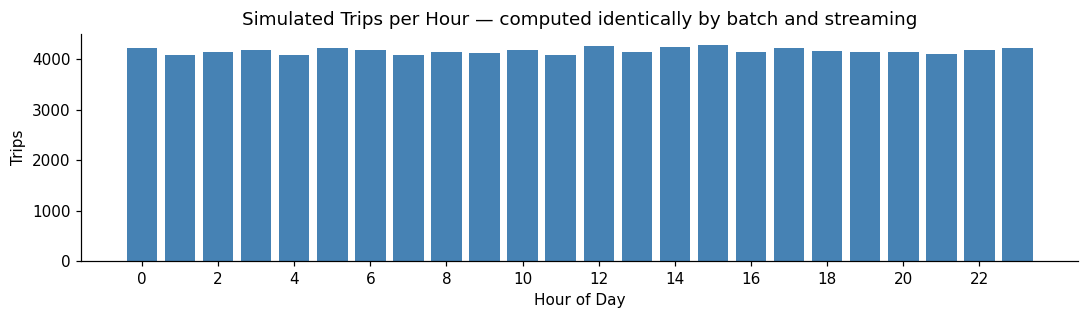

In [27]:
# Visualise hourly trip distribution
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(batch_counts.index, batch_counts.values, color='steelblue', width=0.8)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Trips')
ax.set_title('Simulated Trips per Hour — computed identically by batch and streaming')
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

**Takeaway:** For a finite, in-memory dataset both approaches give the same answer.  
Streaming becomes essential when:
- The dataset is **infinite** (can never store everything)
- You need **low latency** (respond within milliseconds, not after hours of batch processing)
- You need to **bound memory** usage regardless of how long the stream has been running

---
## Part II — Approximate Streaming Algorithms

The formal **Data Stream Model** (MMDS Ch 4) formalises the constraints:
1. Data arrives continuously as a sequence of elements
2. Storage is severely limited compared to data volume
3. Only one (or very few) passes over the data are allowed

Because we can't store everything, we accept **approximation in exchange for efficiency**.

### 2.1 Reservoir Sampling

**Goal:** Maintain a **uniform random sample** of size *k* from a stream of unknown (or infinite) length.

**Algorithm (Vitter's Algorithm R):**
1. Fill the reservoir with the first *k* elements.
2. For the *n*-th element (n > k), keep it with probability **k/n**.
3. If kept, replace a uniformly random element in the reservoir.

**Space:** O(k) — constant regardless of stream length.

**Correctness:** At any point after seeing *n* elements, every element has equal probability *k/n* of being in the sample.

In [28]:
def reservoir_sample(stream, k: int, seed: int = 42) -> list:
    """Return a uniform random sample of size k from an iterable stream.
    Uses O(k) memory regardless of stream length.
    """
    rng = random.Random(seed)
    reservoir = []

    for n, item in enumerate(stream, start=1):
        if n <= k:
            # Phase 1: fill the reservoir
            reservoir.append(item)
        else:
            # Phase 2: keep with probability k/n
            j = rng.randint(1, n)   # random integer in [1, n]
            if j <= k:
                reservoir[j - 1] = item   # replace a random slot

    return reservoir


# ── Demonstration ─────────────────────────────────────────────────────────────
# Stream: integers 0..999,999  (1 million items, but we only keep 1,000)
STREAM_SIZE = 1_000_000
K = 1_000

sample = reservoir_sample(range(STREAM_SIZE), k=K)

print(f'Stream size:  {STREAM_SIZE:,}')
print(f'Sample size:  {len(sample):,}  (O(k) = O({K}) memory)')
print(f'Sample range: [{min(sample)}, {max(sample)}]')
print(f'Sample mean:  {sum(sample)/len(sample):,.0f}  (expected ≈ {STREAM_SIZE//2:,})')

Stream size:  1,000,000
Sample size:  1,000  (O(k) = O(1000) memory)
Sample range: [4404, 999764]
Sample mean:  505,799  (expected ≈ 500,000)


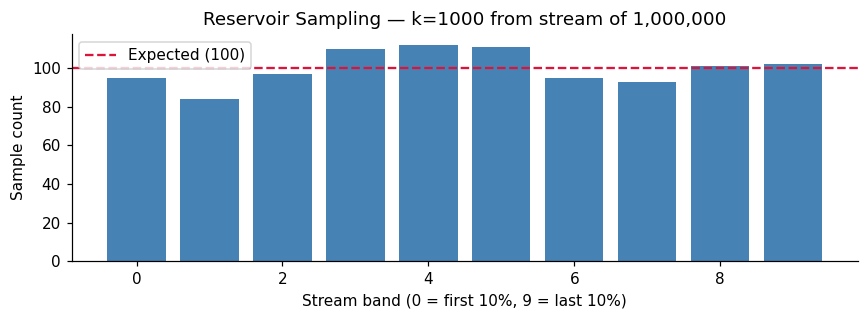

Each band should contain ~ 100 items — confirms uniform coverage.


In [29]:
# Verify uniformity: split the stream into 10 equal bands.
# A uniform sample should have roughly K/10 = 100 items per band.

BANDS = 10
band_size = STREAM_SIZE // BANDS
band_counts = Counter(v // band_size for v in sample)

fig, ax = plt.subplots(figsize=(8, 3))
bands  = range(BANDS)
counts = [band_counts.get(b, 0) for b in bands]
ax.bar(bands, counts, color='steelblue')
ax.axhline(K / BANDS, color='crimson', linestyle='--', label=f'Expected ({K//BANDS})')
ax.set_xlabel('Stream band (0 = first 10%, 9 = last 10%)')
ax.set_ylabel('Sample count')
ax.set_title(f'Reservoir Sampling — k={K} from stream of {STREAM_SIZE:,}')
ax.legend()
plt.tight_layout()
plt.show()

print('Each band should contain ~', K // BANDS, 'items — confirms uniform coverage.')

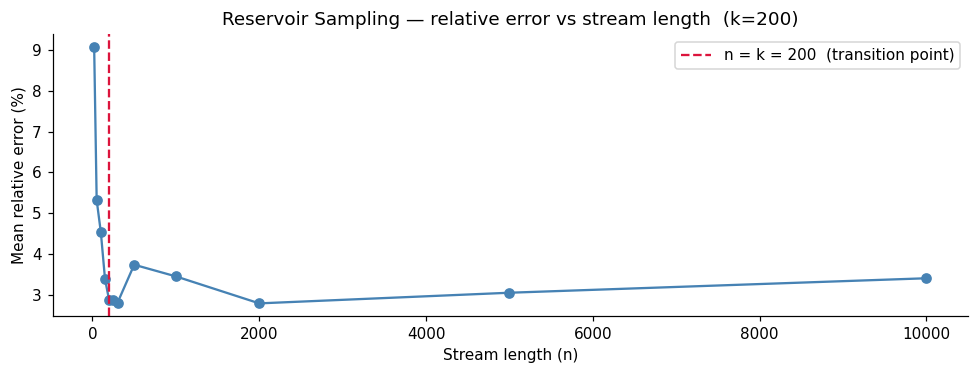

For n ≤ k=200: reservoir holds the entire stream → near-zero error.
For n  > k=200: approximation kicks in → error stabilises (independent of how large n gets).


In [30]:
# Show the transition from perfect recall (n ≤ k) to approximation (n > k).
# When the stream is shorter than the reservoir, every element is kept — error = 0.
# Once n exceeds k, reservoir sampling kicks in and error stabilises at a level
# determined by k, not by how much longer the stream gets.

K_FIXED   = 200
MAX_VALUE = 1000000
TRIALS    = 40
TRUE_MEAN = (MAX_VALUE - 1) / 2

# Range crosses the k=200 threshold to clearly show the transition
stream_lengths = [20, 50, 100, 150, 200, 250, 300, 500,
                  1000, 2000, 5000, 10000]
errors = []

for n in stream_lengths:
    errs = []
    for t in range(TRIALS):
        stream = (random.Random(t * 1000 + i).randint(0, MAX_VALUE - 1) for i in range(n))
        s = reservoir_sample(stream, k=K_FIXED, seed=t)
        errs.append(abs(sum(s) / len(s) - TRUE_MEAN) / TRUE_MEAN * 100)
    errors.append(np.mean(errs))

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(stream_lengths, errors, 'o-', color='steelblue')
ax.axvline(K_FIXED, color='crimson', linestyle='--', label=f'n = k = {K_FIXED}  (transition point)')
ax.set_xlabel('Stream length (n)')
ax.set_ylabel('Mean relative error (%)')
ax.set_title(f'Reservoir Sampling — relative error vs stream length  (k={K_FIXED})')
ax.legend()
plt.tight_layout()
plt.show()

print(f'For n ≤ k={K_FIXED}: reservoir holds the entire stream → near-zero error.')
print(f'For n  > k={K_FIXED}: approximation kicks in → error stabilises (independent of how large n gets).')


**Observation:** The sample error stabilises once the stream is much larger than *k*.  
We get a **constant-quality sample** in constant memory — the streaming miracle.

---
### 2.2 Bloom Filters

**Goal:** Answer "Is element *x* in the set?" using far less memory than storing the set.

**Data structure:** A bit array of size *m* + *k* independent hash functions.

**Insert(x):** Compute h₁(x), h₂(x), …, hₖ(x) → set those bits to 1.

**Query(x):** Check all k positions. If **any** bit is 0 → definitely NOT in set. If **all** bits are 1 → *probably* in set.

**Guarantees:**
- **No false negatives** — if x was inserted, the query always returns true.
- **False positives possible** — an element never inserted may still return true.

**False positive rate:**  
p ≈ (1 − e^(−kn/m))^k  
where n = number of elements inserted, m = bit array size, k = number of hash functions.

In [56]:
class BloomFilter:
    """Simple Bloom filter using k double-hashing-derived positions."""

    def __init__(self, m: int, k: int):
        """
        m : number of bits
        k : number of hash functions
        """
        self.m = m
        self.k = k
        self.bits = bytearray(math.ceil(m / 8))  # bit-packed storage
        self.count = 0

    def _positions(self, item) -> list[int]:
        """Return k bit positions for item using double hashing."""
        # Two independent hash digests
        h1 = int(hashlib.md5(str(item).encode()).hexdigest(), 16)
        h2 = int(hashlib.sha1(str(item).encode()).hexdigest(), 16)
        return [(h1 + i * h2) % self.m for i in range(self.k)]

    def _set_bit(self, pos: int):
        self.bits[pos // 8] |= 1 << (pos % 8)

    def _get_bit(self, pos: int) -> bool:
        return bool(self.bits[pos // 8] & (1 << (pos % 8)))

    def add(self, item):
        for pos in self._positions(item):
            self._set_bit(pos)
        self.count += 1

    def __contains__(self, item) -> bool:
        return all(self._get_bit(pos) for pos in self._positions(item))

    def memory_bytes(self) -> int:
        return len(self.bits)

    @staticmethod
    def optimal_k(m: int, n: int) -> int:
        """Optimal number of hash functions for given m bits and n expected elements."""
        return max(1, round((m / n) * math.log(2)))

    @staticmethod
    def theoretical_fpr(m: int, k: int, n: int) -> float:
        """Theoretical false positive rate."""
        return (1 - math.exp(-k * n / m)) ** k


# ── Demonstration ─────────────────────────────────────────────────────────────
# Imagine we have a set of 10,000 known bike-trip IDs.
# We want to quickly check if an incoming trip ID was already seen.

N_INSERT = 10_000
M_BITS   = 100_000          # ~12 KB  vs  ~80 KB for a Python set
K_HASH   = BloomFilter.optimal_k(M_BITS, N_INSERT)

bf = BloomFilter(m=M_BITS, k=K_HASH)

known_ids  = set(range(N_INSERT))
unknown_ids = range(N_INSERT, 2 * N_INSERT)

for trip_id in known_ids:
    bf.add(trip_id)

# False negatives?
false_negatives = sum(1 for tid in known_ids if tid not in bf)

# False positives?
false_positives = sum(1 for tid in unknown_ids if tid in bf)

theoretical = BloomFilter.theoretical_fpr(M_BITS, K_HASH, N_INSERT)

print(f'Bit array size  : {M_BITS:,} bits  ({bf.memory_bytes():,} bytes ≈ {bf.memory_bytes()/1024:.1f} KB)')
print(f'Hash functions  : k = {K_HASH}')
print(f'Elements inserted: {N_INSERT:,}')
print()
print(f'False negatives  : {false_negatives}  (guaranteed 0)')
print(f'False positives  : {false_positives} / {N_INSERT:,}  ({false_positives/N_INSERT*100:.2f}%)')
print(f'Theoretical FPR  : {theoretical*100:.2f}%')

Bit array size  : 100,000 bits  (12,500 bytes ≈ 12.2 KB)
Hash functions  : k = 7
Elements inserted: 10,000

False negatives  : 0  (guaranteed 0)
False positives  : 96 / 10,000  (0.96%)
Theoretical FPR  : 0.82%


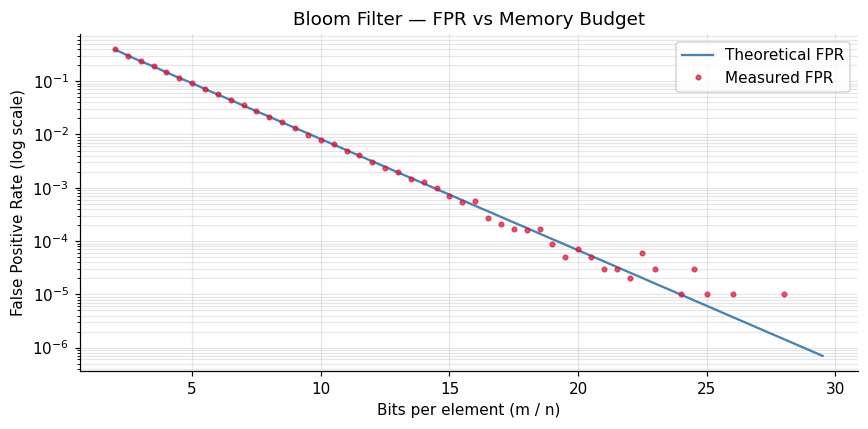

Rule of thumb: ~10 bits/element gives < 1% FPR.  ~20 bits/element gives < 0.01% FPR.


In [57]:
# How does false positive rate vary with the bits-per-element ratio?

bits_per_element = np.arange(2, 30, 0.5)
n_elements = 100000

theoretical_fprs = []
measured_fprs    = []

for bpe in bits_per_element:
    m = int(bpe * n_elements)
    k = BloomFilter.optimal_k(m, n_elements)

    bf_exp = BloomFilter(m=m, k=k)
    for i in range(n_elements):
        bf_exp.add(i)

    fp = sum(1 for i in range(n_elements, 2 * n_elements) if i in bf_exp)
    measured_fprs.append(fp / n_elements)
    theoretical_fprs.append(BloomFilter.theoretical_fpr(m, k, n_elements))

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(bits_per_element, theoretical_fprs, label='Theoretical FPR', color='steelblue')
ax.semilogy(bits_per_element, measured_fprs, 'o', markersize=3,
            label='Measured FPR', color='crimson', alpha=0.7)
ax.set_xlabel('Bits per element (m / n)')
ax.set_ylabel('False Positive Rate (log scale)')
ax.set_title('Bloom Filter — FPR vs Memory Budget')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print('Rule of thumb: ~10 bits/element gives < 1% FPR.  ~20 bits/element gives < 0.01% FPR.')

**Practical use:** Bloom filters are used in Cassandra, HBase, and Spark to skip files/partitions that definitely do not contain a queried key — saving expensive I/O on every lookup.

---
### 2.3 AMS Sketch (Frequency Moments)

The **AMS Sketch** (Alon-Matias-Szegedy) estimates **frequency moments** of a data stream.

The *k*-th frequency moment of a stream is defined as:

$$F_k = \sum_{i} c_i^k$$

where $c_i$ is the count of element $i$.

**F₀** = number of distinct elements  
**F₁** = total stream length  
**F₂** = sum of squared frequencies — measures how concentrated ("heavy hitter"-heavy) the stream is

**Why F₂ matters:** F₂ is large when a few items dominate (skewed distribution).  
It is the basis for detecting heavy hitters and measuring stream skewness.

**AMS F₂ estimator:** Pick a random {+1, −1} hash function $h(i)$.  
Maintain a counter $X = \sum_i h(i) \cdot c_i$.  
Then $X^2$ is an **unbiased estimator of F₂**.  
Average many independent such counters to reduce variance.

In [38]:
class AMSSketch:
    """AMS Sketch for estimating F2 (second frequency moment)."""

    def __init__(self, n_estimators: int = 64, seed: int = 42):
        """
        n_estimators : number of independent ±1 hash functions
        """
        self.n = n_estimators
        # Each estimator uses a different seed for its hash family
        self._seeds = [seed + i for i in range(n_estimators)]
        self._counters = [0] * n_estimators

    def _hash(self, item, seed: int) -> int:
        """Return +1 or -1 for (item, seed) pair."""
        h = int(hashlib.md5(f'{seed}:{item}'.encode()).hexdigest(), 16)
        return 1 if h % 2 == 0 else -1

    def update(self, item):
        """Process one stream element."""
        for i in range(self.n):
            self._counters[i] += self._hash(item, self._seeds[i])

    def estimate_f2(self) -> float:
        """Return estimated F2 = sum of squared frequencies."""
        # Each counter^2 is an unbiased estimator; average for lower variance
        return np.mean([c ** 2 for c in self._counters])


# ── Demonstration ─────────────────────────────────────────────────────────────
# Construct a skewed stream: most trips depart from a few popular stations.
# Station probabilities follow a Zipf distribution.

N_STATIONS = 61
STREAM_LEN = 200_000

rng2 = np.random.default_rng(SEED)

# Zipf weights: station 1 is most popular
weights = 1.0 / np.arange(1, N_STATIONS + 1)  # Zipf(1)
weights /= weights.sum()

stream_stations = rng2.choice(N_STATIONS, size=STREAM_LEN, p=weights)

# True F2
true_counts = Counter(stream_stations)
true_f2 = sum(c ** 2 for c in true_counts.values())

# AMS estimate (only O(n_estimators) memory, not O(N_STATIONS))
sketch = AMSSketch(n_estimators=128, seed=SEED)
for s in stream_stations:
    sketch.update(s)

est_f2 = sketch.estimate_f2()

print(f'Stream length : {STREAM_LEN:,}')
print(f'Unique stations: {N_STATIONS}')
print()
print(f'True F₂      : {true_f2:,.0f}')
print(f'AMS estimate : {est_f2:,.0f}')
print(f'Error        : {abs(est_f2 - true_f2) / true_f2 * 100:.2f}%')

Stream length : 200,000
Unique stations: 61

True F₂      : 2,956,061,238
AMS estimate : 3,367,528,002
Error        : 13.92%


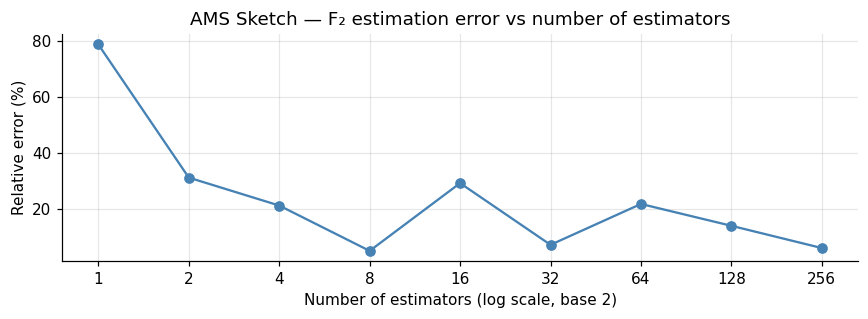

In [39]:
# Accuracy vs number of estimators
estimator_counts = [1, 2, 4, 8, 16, 32, 64, 128, 256]
errors_f2 = []

for ne in estimator_counts:
    sk = AMSSketch(n_estimators=ne, seed=SEED)
    for s in stream_stations:
        sk.update(s)
    errors_f2.append(abs(sk.estimate_f2() - true_f2) / true_f2 * 100)

fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogx(estimator_counts, errors_f2, 'o-', color='steelblue', base=2)
ax.set_xlabel('Number of estimators (log scale, base 2)')
ax.set_ylabel('Relative error (%)')
ax.set_title('AMS Sketch — F₂ estimation error vs number of estimators')
ax.grid(True, alpha=0.3)
ax.set_xticks(estimator_counts)
ax.set_xticklabels(estimator_counts)
plt.tight_layout()
plt.show()

**Key insight:** With only 128 counters we estimate F₂ of a 200k-element stream over 61 distinct elements within a few percent error.  
The sketch uses **O(n_estimators)** memory, completely independent of stream length.

---
## Part III — Event Time vs Processing Time

In real systems, events are generated at the **source** (event time), then travel through a network before reaching the processing engine (processing time).

Network delays cause events to arrive **out of order** with respect to their event timestamps.

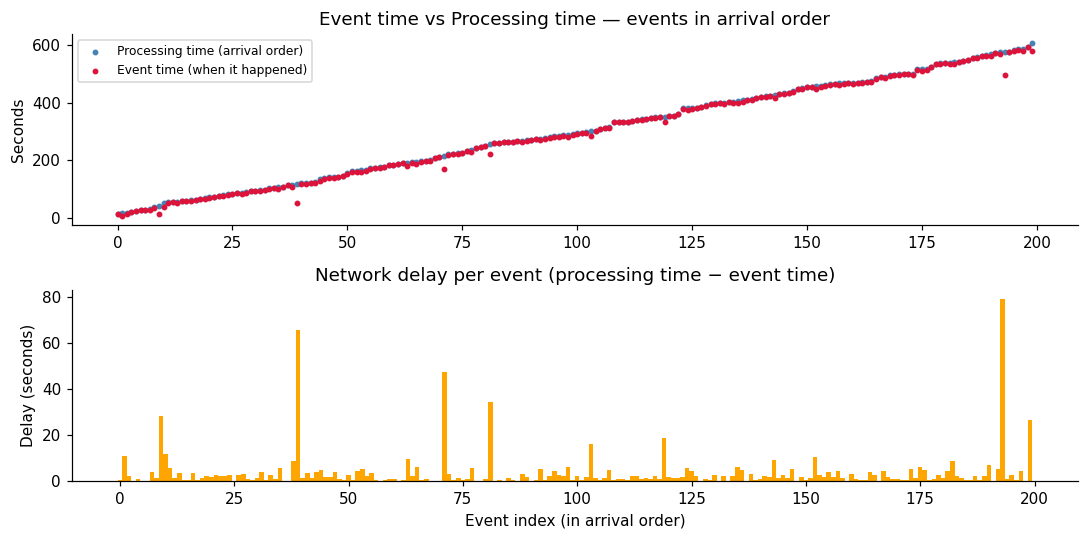

Events delayed > 10 s: 11 (5.5%)
Max delay: 79.0 s


In [40]:
# Simulate out-of-order event arrival
# Each event has an event_time (when it happened) and an arrival_time (when we receive it).

NUM_EVENTS_RT = 200
rng3 = np.random.default_rng(SEED)

# Event times: uniformly spread over 600 seconds (10 minutes)
event_times = np.sort(rng3.uniform(0, 600, NUM_EVENTS_RT))

# Network delay: mostly small (0-2 s) but occasionally very large (up to 60 s)
base_delay  = rng3.exponential(scale=2, size=NUM_EVENTS_RT)
big_delay   = rng3.exponential(scale=30, size=NUM_EVENTS_RT) * rng3.binomial(1, 0.05, NUM_EVENTS_RT)
total_delay = base_delay + big_delay

arrival_times = event_times + total_delay

# Sort by arrival time (this is the order the engine sees them)
order_by_arrival = np.argsort(arrival_times)
et_sorted = event_times[order_by_arrival]
at_sorted = arrival_times[order_by_arrival]

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=False)

axes[0].scatter(range(NUM_EVENTS_RT), at_sorted, s=8, color='steelblue', label='Processing time (arrival order)')
axes[0].scatter(range(NUM_EVENTS_RT), et_sorted,  s=8, color='crimson',   label='Event time (when it happened)')
axes[0].set_ylabel('Seconds')
axes[0].set_title('Event time vs Processing time — events in arrival order')
axes[0].legend(loc='upper left', fontsize=8)

axes[1].bar(range(NUM_EVENTS_RT), at_sorted - et_sorted, color='orange', width=1)
axes[1].set_xlabel('Event index (in arrival order)')
axes[1].set_ylabel('Delay (seconds)')
axes[1].set_title('Network delay per event (processing time − event time)')

plt.tight_layout()
plt.show()

late = (at_sorted - et_sorted > 10).sum()
print(f'Events delayed > 10 s: {late} ({late/NUM_EVENTS_RT*100:.1f}%)')
print(f'Max delay: {(at_sorted - et_sorted).max():.1f} s')

**Consequence:** If we use *processing time* to compute a "trips in the last 10 minutes" window, a late-arriving event from 12 minutes ago will be silently dropped — corrupting the result.  
We must use **event time** and accept that windows cannot be finalised immediately.

---
## Part IV — Windows and Watermarks

To aggregate over event time we define **windows**.  
To decide when a window is complete we use **watermarks**.

### Window types
| Type | Description | Example |
|---|---|---|
| **Tumbling** | Fixed-size, non-overlapping | Count trips every 5 minutes |
| **Sliding** | Fixed-size, overlapping | Count trips in the last 10 min, updated every 5 min |
| **Session** | Variable-size, gap-based | Group trips within 30 min of each other |

In [41]:
# Generate a realistic 2-hour event stream with rush-hour shape

TOTAL_SECONDS = 7200   # 2 hours
TOTAL_TRIPS   = 5_000
rng4 = np.random.default_rng(SEED)

# Gaussian bump around 1 hour mark (rush hour)
raw = rng4.normal(loc=TOTAL_SECONDS * 0.55, scale=TOTAL_SECONDS * 0.1, size=TOTAL_TRIPS)
et  = np.clip(raw, 0, TOTAL_SECONDS - 1)

print(f'Generated {len(et):,} events over {TOTAL_SECONDS/60:.0f} minutes.')

Generated 5,000 events over 120 minutes.


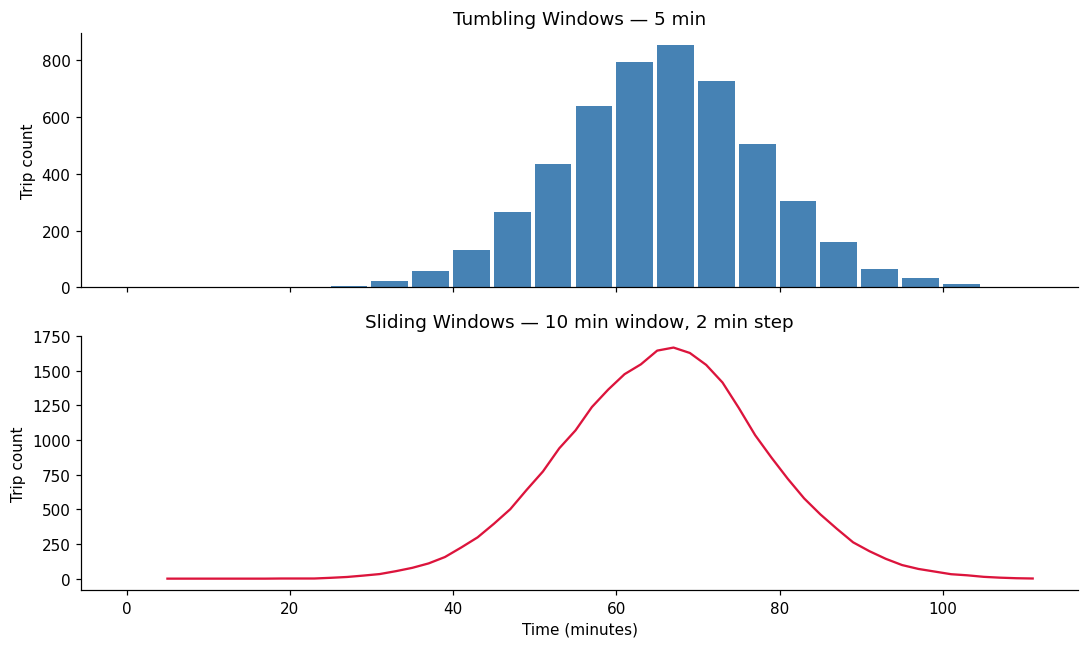

In [42]:
# ── Tumbling Windows ─────────────────────────────────────────────────────────
TUMBLE_SIZE = 300   # 5-minute windows

def tumbling_windows(event_times: np.ndarray, window_sec: int) -> pd.DataFrame:
    """Count events in non-overlapping fixed-size windows."""
    window_ids = (event_times // window_sec).astype(int)
    counts = Counter(window_ids)
    n_windows = int(event_times.max() // window_sec) + 1
    return pd.DataFrame({
        'window_start': [w * window_sec / 60 for w in range(n_windows)],
        'count': [counts.get(w, 0) for w in range(n_windows)]
    })


# ── Sliding Windows ───────────────────────────────────────────────────────────
SLIDE_WINDOW = 600  # 10-minute window
SLIDE_STEP   = 120  # slide every 2 minutes

def sliding_windows(event_times: np.ndarray, window_sec: int, step_sec: int) -> pd.DataFrame:
    """Count events in overlapping sliding windows."""
    results = []
    for t_start in range(0, int(event_times.max()), step_sec):
        t_end = t_start + window_sec
        cnt = ((event_times >= t_start) & (event_times < t_end)).sum()
        results.append({'window_start': t_start / 60, 'count': cnt})
    return pd.DataFrame(results)


tdf = tumbling_windows(et, TUMBLE_SIZE)
sdf = sliding_windows(et, SLIDE_WINDOW, SLIDE_STEP)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].bar(tdf['window_start'], tdf['count'], width=TUMBLE_SIZE/60 * 0.9,
            color='steelblue', align='edge')
axes[0].set_ylabel('Trip count')
axes[0].set_title(f'Tumbling Windows — {TUMBLE_SIZE//60} min')

axes[1].plot(sdf['window_start'] + SLIDE_WINDOW/60/2, sdf['count'],
             color='crimson', linewidth=1.5)
axes[1].set_ylabel('Trip count')
axes[1].set_xlabel('Time (minutes)')
axes[1].set_title(f'Sliding Windows — {SLIDE_WINDOW//60} min window, {SLIDE_STEP//60} min step')

plt.tight_layout()
plt.show()

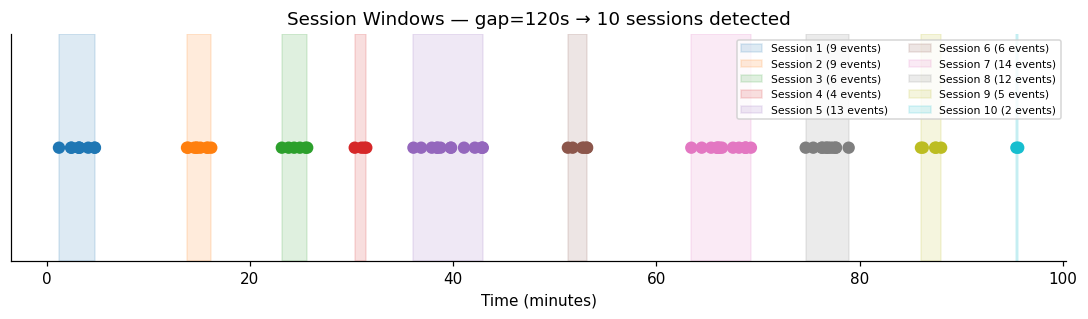

In [43]:
# ── Session Windows ───────────────────────────────────────────────────────────
# Events are grouped if the gap between consecutive events is < session_gap seconds.
# This is useful for user activity sessions.

# Simulate a single user's click events over 1 hour with quiet periods
session_events = []
rng5 = np.random.default_rng(SEED)
t = 0.0
for _ in range(80):
    # Short inter-event time (active period)
    t += rng5.exponential(30)
    session_events.append(t)
    if rng5.random() < 0.15:  # ~15% chance of a long gap (session break)
        t += rng5.uniform(200, 600)

session_events = np.array(session_events)

SESSION_GAP = 120   # 2-minute gap triggers a new session

# Assign session IDs
session_ids = [0]
for i in range(1, len(session_events)):
    gap = session_events[i] - session_events[i - 1]
    session_ids.append(session_ids[-1] + (1 if gap > SESSION_GAP else 0))

session_ids = np.array(session_ids)
n_sessions  = session_ids[-1] + 1
session_sizes = Counter(session_ids)

fig, ax = plt.subplots(figsize=(10, 3))
colors = plt.cm.tab10(session_ids % 10)
ax.scatter(session_events / 60, np.zeros(len(session_events)),
           c=colors, s=50, zorder=3)

# Draw session spans
for sid in range(n_sessions):
    mask = session_ids == sid
    span_start = session_events[mask].min() / 60
    span_end   = session_events[mask].max() / 60
    ax.axvspan(span_start, span_end, alpha=0.15,
               color=plt.cm.tab10(sid % 10),
               label=f'Session {sid+1} ({session_sizes[sid]} events)')

ax.set_yticks([])
ax.set_xlabel('Time (minutes)')
ax.set_title(f'Session Windows — gap={SESSION_GAP}s → {n_sessions} sessions detected')
ax.legend(loc='upper right', fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

---
### 4.1 Watermarks and Late Data

A **watermark** tells the streaming engine:  
*"I believe all events with event_time ≤ watermark have already arrived."*

Typically: `watermark = max_event_time_seen − allowed_lateness`

A window is **finalised** once the watermark passes its end time.

- **Short watermark** (small allowed lateness) → fast output, but late events are discarded
- **Long watermark** (large allowed lateness) → more correct, but higher latency

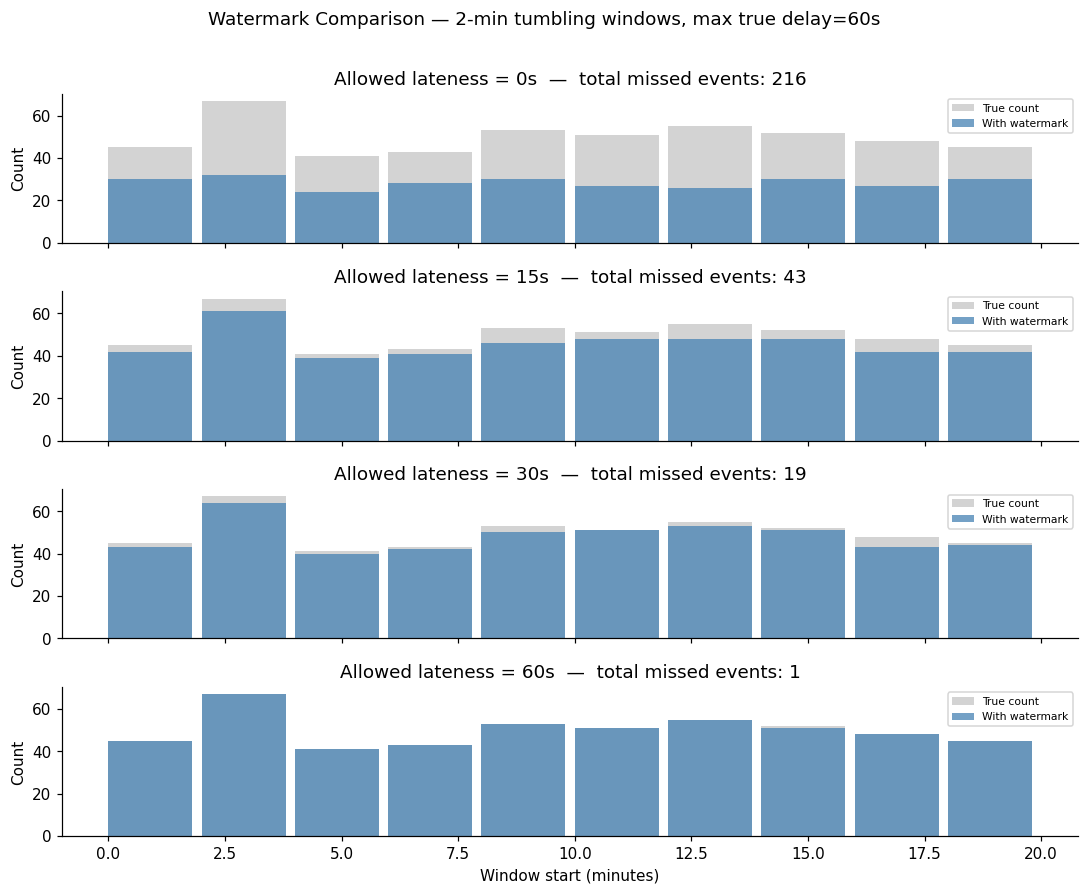

In [44]:
# Simulate processing a stream with late data and different watermark policies.

WIN_SIZE    = 120   # 2-minute tumbling windows
MAX_DELAY   = 60    # true maximum delay in the system

rng6 = np.random.default_rng(SEED)

n_ev = 500
ev_times2 = np.sort(rng6.uniform(0, 1200, n_ev))  # 20 minutes
delays2   = rng6.exponential(5, n_ev) + rng6.uniform(0, MAX_DELAY, n_ev) * rng6.binomial(1, 0.08, n_ev)
arr_times2 = ev_times2 + delays2

# Sort by arrival (engine sees events in this order)
order = np.argsort(arr_times2)
ev_sorted  = ev_times2[order]
arr_sorted = arr_times2[order]

# Ground truth: exact count per window
true_counts = Counter((ev_times2 // WIN_SIZE).astype(int))

def simulate_watermark(allowed_lateness: float):
    """Process stream with a given watermark and return per-window counts."""
    buffers     = defaultdict(list)   # window_id -> buffered event times
    finalised   = {}                  # window_id -> final count
    watermark   = 0.0

    for et, at in zip(ev_sorted, arr_sorted):
        # Advance watermark to current max event time minus lateness
        watermark = max(watermark, et - allowed_lateness)

        win = int(et // WIN_SIZE)
        win_end = (win + 1) * WIN_SIZE

        if et >= watermark:          # not yet dropped as too-late
            buffers[win].append(et)

        # Finalise windows whose end is before the watermark
        for w in list(buffers.keys()):
            if (w + 1) * WIN_SIZE <= watermark and w not in finalised:
                finalised[w] = len(buffers[w])

    # Finalise remaining windows
    for w in buffers:
        if w not in finalised:
            finalised[w] = len(buffers[w])

    return finalised


lateness_configs = [0, 15, 30, 60]
results = {lat: simulate_watermark(lat) for lat in lateness_configs}

n_windows = int(ev_times2.max() // WIN_SIZE) + 1

fig, axes = plt.subplots(len(lateness_configs), 1, figsize=(10, 8), sharex=True)

for ax, lat in zip(axes, lateness_configs):
    true_vals  = [true_counts.get(w, 0) for w in range(n_windows)]
    est_vals   = [results[lat].get(w, 0) for w in range(n_windows)]
    xs = [w * WIN_SIZE / 60 for w in range(n_windows)]

    ax.bar(xs, true_vals, width=WIN_SIZE/60 * 0.9, align='edge',
           color='lightgrey', label='True count', zorder=1)
    ax.bar(xs, est_vals,  width=WIN_SIZE/60 * 0.9, align='edge',
           color='steelblue', alpha=0.75, label='With watermark', zorder=2)
    errors = sum(abs(true_counts.get(w, 0) - results[lat].get(w, 0)) for w in range(n_windows))
    ax.set_title(f'Allowed lateness = {lat}s  —  total missed events: {errors}')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

axes[-1].set_xlabel('Window start (minutes)')
plt.suptitle(f'Watermark Comparison — 2-min tumbling windows, max true delay={MAX_DELAY}s', y=1.01)
plt.tight_layout()
plt.show()

In [45]:
# Quantify the accuracy vs latency trade-off
total_events = len(ev_times2)

print(f'Max true delay in this simulation: {delays2.max():.1f}s')
print(f'Total events: {total_events}\n')
print(f'{"Allowed lateness":>20}  {"Missed events":>14}  {"Error %":>8}')
print('-' * 50)
for lat in lateness_configs:
    missed = sum(
        abs(true_counts.get(w, 0) - results[lat].get(w, 0))
        for w in range(n_windows)
    )
    print(f'{lat:>18}s  {missed:>14,}  {missed/total_events*100:>7.2f}%')

print()
print('Interpretation:')
print('  lateness=0s  → fastest output, but drops all events delayed > 0s')
print(f'  lateness={MAX_DELAY}s → covers true maximum delay, near-perfect accuracy but adds {MAX_DELAY}s latency')

Max true delay in this simulation: 66.0s
Total events: 500

    Allowed lateness   Missed events   Error %
--------------------------------------------------
                 0s             216    43.20%
                15s              43     8.60%
                30s              19     3.80%
                60s               1     0.20%

Interpretation:
  lateness=0s  → fastest output, but drops all events delayed > 0s
  lateness=60s → covers true maximum delay, near-perfect accuracy but adds 60s latency


---
## Part V — Structured Streaming (Simulated)

Spark Structured Streaming treats a stream as an **unbounded table** that grows over time.  
Developers write standard DataFrame queries; the engine runs them incrementally.

We simulate this with pandas, processing micro-batches one at a time and maintaining a **running result table** — analogous to Spark's Update output mode.

In [46]:
# ── Simulated Structured Streaming engine ─────────────────────────────────────

class MicroBatchEngine:
    """
    Simulates Spark Structured Streaming's micro-batch execution.

    Query: Count trips per station per 5-minute tumbling window.
    Output mode: Update (only changed rows emitted each trigger).
    """

    WINDOW_SEC = 300   # 5-minute windows

    def __init__(self):
        # This is the "unbounded result table"
        self.result_table = {}    # (window_id, station_id) -> count
        self.batch_id     = 0

    def process_batch(self, batch: pd.DataFrame) -> pd.DataFrame:
        """Process one micro-batch and return updated rows."""
        if batch.empty:
            return pd.DataFrame()

        batch = batch.copy()
        batch['window'] = (batch['event_time'] // self.WINDOW_SEC).astype(int)

        updated_keys = set()
        for _, row in batch.iterrows():
            key = (row['window'], row['station_id'])
            self.result_table[key] = self.result_table.get(key, 0) + 1
            updated_keys.add(key)

        self.batch_id += 1

        # Emit only updated rows (Update mode)
        return pd.DataFrame([
            {
                'window_start_min': k[0] * self.WINDOW_SEC / 60,
                'station_id': k[1],
                'trip_count': self.result_table[k]
            }
            for k in updated_keys
        ]).sort_values(['window_start_min', 'station_id'])


# ── Generate 30 minutes of streaming events ───────────────────────────────────
rng7 = np.random.default_rng(SEED)
DURATION = 1800   # 30 minutes

all_events_et  = np.sort(rng7.uniform(0, DURATION, 3000))
all_events_st  = rng7.integers(1, 62, 3000)

full_df = pd.DataFrame({'event_time': all_events_et, 'station_id': all_events_st})

# Split into micro-batches (trigger every 60 seconds of stream time)
TRIGGER_INTERVAL = 60
engine = MicroBatchEngine()
batch_summaries  = []

for trigger_t in range(0, DURATION, TRIGGER_INTERVAL):
    batch = full_df[
        (full_df['event_time'] >= trigger_t) &
        (full_df['event_time'] <  trigger_t + TRIGGER_INTERVAL)
    ]
    updates = engine.process_batch(batch)
    n_rows = len(full_df[full_df['event_time'] < trigger_t + TRIGGER_INTERVAL])
    batch_summaries.append({
        'trigger_t': trigger_t,
        'batch_size': len(batch),
        'updated_rows': len(updates),
        'total_processed': n_rows,
    })

print('Final result table (top 10 rows):')
final = pd.DataFrame([
    {'window_start_min': k[0] * engine.WINDOW_SEC / 60,
     'station_id': k[1],
     'trip_count': v}
    for k, v in engine.result_table.items()
]).sort_values('trip_count', ascending=False)
print(final.head(10).to_string(index=False))

Final result table (top 10 rows):
 window_start_min  station_id  trip_count
             15.0         9.0          16
             25.0         2.0          16
             25.0        32.0          16
              5.0        35.0          15
              5.0        21.0          14
              0.0         5.0          14
             15.0        26.0          14
             20.0        32.0          14
             15.0         5.0          14
              0.0        15.0          14


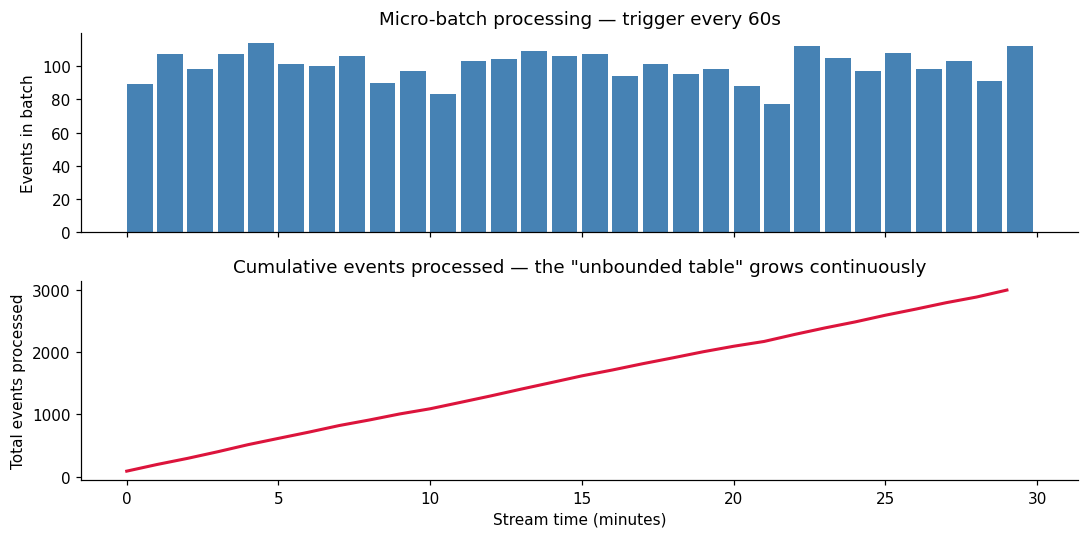

In [47]:
# Visualise: what each micro-batch trigger produced
summary_df = pd.DataFrame(batch_summaries)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

axes[0].bar(summary_df['trigger_t'] / 60, summary_df['batch_size'],
            width=TRIGGER_INTERVAL/60 * 0.85, align='edge', color='steelblue')
axes[0].set_ylabel('Events in batch')
axes[0].set_title(f'Micro-batch processing — trigger every {TRIGGER_INTERVAL}s')

axes[1].plot(summary_df['trigger_t'] / 60, summary_df['total_processed'],
             color='crimson', linewidth=2)
axes[1].set_ylabel('Total events processed')
axes[1].set_xlabel('Stream time (minutes)')
axes[1].set_title('Cumulative events processed — the "unbounded table" grows continuously')

plt.tight_layout()
plt.show()

In [48]:
# Compare the three output modes:
#  Append  — only newly finalised rows
#  Update  — only rows that changed this batch
#  Complete — the entire result table every batch

print('Output Mode Comparison (after 30 minutes, 30 triggers)\n')
print(f'{"Mode":>12}  {"Rows emitted (total across all triggers)":>42}  Notes')
print('-' * 80)

total_result_rows = len(engine.result_table)
total_triggers    = len(batch_summaries)
avg_updated       = int(sum(b['updated_rows'] for b in batch_summaries) / total_triggers)

print(f'{"Append":>12}  {total_result_rows:>42,}  Emits rows when windows are finalised (with watermark)')
print(f'{"Update":>12}  {sum(b["updated_rows"] for b in batch_summaries):>42,}  Only changed rows each trigger (~{avg_updated} rows/trigger)')
print(f'{"Complete":>12}  {total_result_rows * total_triggers:>42,}  Rewrites entire table every trigger — expensive!')

Output Mode Comparison (after 30 minutes, 30 triggers)

        Mode    Rows emitted (total across all triggers)  Notes
--------------------------------------------------------------------------------
      Append                                         366  Emits rows when windows are finalised (with watermark)
      Update                                       1,480  Only changed rows each trigger (~49 rows/trigger)
    Complete                                      10,980  Rewrites entire table every trigger — expensive!


---
## Summary

| Concept | Key Idea | Algorithm/Mechanism |
|---|---|---|
| Batch vs Streaming | Bounded vs unbounded data | Single-pass + in-memory state |
| Reservoir Sampling | Uniform sample in O(k) memory | Accept *i*-th item with prob *k/i* |
| Bloom Filter | Set membership in sublinear memory | Bit array + k hash functions |
| AMS Sketch | Frequency moments in sublinear memory | ±1 random projections |
| Event time | When the event happened (embedded in data) | Read timestamp from record |
| Processing time | When the engine sees the event | Wall-clock of machine |
| Watermark | Threshold for declaring a window complete | max(event_time) − allowed_lateness |
| Tumbling window | Fixed, non-overlapping | t // window_size |
| Sliding window | Fixed-size, overlapping | [t, t+w) updated every step |
| Session window | Gap-based, variable-size | Merge events within gap threshold |
| Structured Streaming | Unbounded table model | Standard DataFrame API, micro-batches |

---
## Optional Exercises

1. **Reservoir Sampling** — Modify `reservoir_sample` to track *how many times each element was in the reservoir* across 1000 independent runs on a stream of length 10,000 with k=100. Plot a histogram. What distribution do you expect?

2. **Bloom Filter** — Build a Bloom filter that achieves a FPR ≤ 0.5% for 50,000 elements. What is the minimum number of bits required? Use the formula: m = −n·ln(p) / (ln 2)²

3. **AMS Sketch** — Compare F₂ estimates for (a) a uniform stream and (b) a highly skewed Zipf stream of the same length. Why does F₂ differ so much between the two?

4. **Watermarks** — Re-run the watermark simulation (`simulate_watermark`) for allowed_lateness values from 0 to 120 seconds in steps of 5. Plot missed events vs allowed lateness. At what threshold do missed events drop to near zero?

5. **Window Types** — Using the simulated stream in Part IV, implement a **session window** that groups events within a gap of 45 seconds. How does the number of sessions change if you increase the gap to 90 seconds?